<a href="https://colab.research.google.com/github/PriFranca/Estudo-Ds/blob/master/bootcamp_aula_estati%CC%81stica_descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy.stats import mode as scipy_mode
from scipy.stats import (shapiro,
                         normaltest,
                         bartlett,
                         ttest_ind,
                         kruskal,
                         norm)

# Estatística Descritiva

A estatística descritiva é a etapa inicial da análise utilizada para descrever e resumir dados de interesse. Os conceitos por trás deste tipo de análise são largamente utilizados durante a etapa de Análise Exploratória de dados (fase inicial do processo de criação de um modelo preditivo).

A seguir, vamos explorar um pouco dos conceitos de estatística descritiva:

### Variável

Cada uma das características da população, como peso, altura, sexo ou idade, é denominada de uma **variável** (feature). As variáveis podem assumir diferentes valores, que basicamente podem ser separados em:

<img src="images/feature.jpg" width="400" height="100"/>

As variáveis **quantitativas** (ou numéricas) se referem a características que podem ser descritas por números. Já as variáveis **qualitativas** (ou categóricas) são as características que são definidas por grupos, ou seja, representam uma classificação dos indivíduos.

**1. Variável quantitativa discreta**: são variáveis numéricas que têm um número `contável de valores` entre quaisquer dois valores. Uma variável discreta é sempre numérica. Por exemplo, o número de reclamações de clientes ou o número de falhas ou defeitos.

**2. Variável quantitativa contínua**: são variáveis numéricas que têm um número `infinito de valores` entre dois valores quaisquer. Uma variável contínua pode ser numérica ou de data/hora. Por exemplo, o comprimento de uma peça ou a data e hora em que um pagamento é recebido.

**3. Variável qualitativa nominal**: são variáveis categóricas que não possuem uma ordem natural. Por exemplo, nomes, cores e sexo.

**4. Variável qualitativa ordinal**: são variáveis categóricas que podem ser ordenadas. Por exemplo, (pequeno, médio, grande), classe social (baixa, média, alta), grau de instrução (básico, médio, graduação, pós-graduação).

In [ ]:
milsa_dataset = pd.read_csv('data/milsa.csv')
milsa_dataset.head()

,funcionario,estado_civil,escolaridade,filhos,salario,anos,meses,regiao
0,1,solteiro,1o Grau,NaN,300.00,26,3,interior
1,2,casado,1o Grau,1.0,4.56,32,10,capital
2,3,casado,1o Grau,2.0,5.25,36,5,capital
3,4,solteiro,2o Grau,NaN,5.73,20,10,outro
4,5,solteiro,1o Grau,NaN,6.26,40,7,outro


#### Q1) Qual o **tipo** de cada variável acima?

### Amostragem

A exploração de dados de um grande conjunto de dados geralmente exige primeiro a geração de uma amostra de dados pequena e representativa que possa ser facilmente visualizada e interpretada a fim de  gerar insights.

<img src="images/sampling.jpg" width="400" height="100"/>

As têcnicas de amostragens (`data sampling`) pode ser agrupadas em:
- **Probabilística**
    - Amostragem Aleatória Simples
    - Amostragem Aleatória Estratificada
    - Amostragem Sistemática
    - Amostragem Multi-Estágio
- **Não probabilística**
    - Amostragem por Conveniência
    - Amostragem Intencional
    - Amostragem por Cota    

A diferença básica entre elas é se a seleção de amostras envolve **aleatorização** ou não.

### `Amostragem estratificada` (probabilística)

<img src="images/stratified_sampling.jpg" width="300" height="100"/>

### `Amostragem por Cota` (não probabilística)

<img src="images/quota_sampling.jpg" width="400" height="100"/>

### Medidas de Tendência Central

In [ ]:
milsa_dataset['salario'].values

array([ 300.  ,    4.56,    5.25,    5.73,    6.26,    6.66,    6.86,
          7.39,    7.59,    7.44,    8.12,  200.5 ,    8.74,    8.95,
          9.13,    9.35,    9.77,    9.8 , 1000.5 ,   10.76,   11.06,
         11.59,   12.  ,   12.79,   13.23,   13.6 ,   13.85,   14.69,
         14.71,   15.99,   16.22,   16.61,   17.26,   18.75,   19.4 ,
         23.3 ])

### `média`

A média busca refletir o valor de todas as observações. Seu valor é obtido por meio do somatótio de todos os elementos da amostra divido pelo número total de elementos.

In [ ]:
milsa_dataset['salario'].mean()#pandas

52.17805555555556

In [ ]:
np.mean(milsa_dataset.salario)#numpy

52.17805555555556

In [ ]:
scipy.mean(milsa_dataset.salario)#scipy

52.17805555555556

### `mediana`

A mediana corresponde ao valor que a **divide a amostra ao meio**, isto é, **50%** dos elementos da amostra são **menores ou iguais** à mediana e os outros **50%** são **maiores ou iguais** à mediana.

Considerando que a amostra de n elementes está ordenada, o cálculo da mediana obedece as seguintes condições:
- Se n é ímpar, a mediana é o elemento central.
- Se n é par, a mediana é média dos dois elementos centrais.

In [ ]:
milsa_dataset['salario'].median()#pandas

11.325

In [ ]:
np.median(milsa_dataset.salario)#numpy

11.325

In [ ]:
scipy.median(milsa_dataset.salario)#scipy

11.325

### `moda`

A moda corresponde ao valor que surge com mais frequência se os dados são `discretos`, ou o intervalo de classe com maior frequência se os dados são `contínuos`.

In [ ]:
milsa_dataset['estado_civil'].value_counts()

casado      20
solteiro    16
Name: estado_civil, dtype: int64

In [ ]:
milsa_dataset['estado_civil'].mode()#pandas

0    casado
dtype: object

In [ ]:
scipy_mode(milsa_dataset.estado_civil)#scipy

ModeResult(mode=array(['casado'], dtype=object), count=array([20]))

### Q2) Em que situação é mais adequado utilizar a média? E a mediana?

In [ ]:
plot = milsa_dataset['salario'].hist()
print('Média', milsa_dataset['salario'].mean(),'|','Médiana:', milsa_dataset['salario'].median())

Média 52.17805555555556 | Médiana: 11.325


Média 11.436666666666667 | Médiana: 10.76


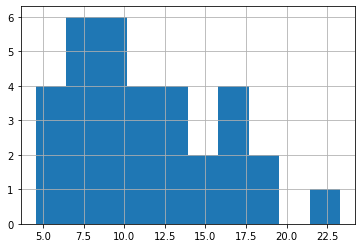

In [ ]:
filtered_dataset = milsa_dataset.copy()
filtered_dataset = filtered_dataset.loc[filtered_dataset['salario'] < 200]
plot = filtered_dataset.salario.hist()
print('Média', filtered_dataset['salario'].mean(),'|','Médiana:', filtered_dataset['salario'].median())

### Medidas de Dispersão

Um aspecto importante no estudo descritivo de um conjunto de dados, é o da determinação da variabilidade ou dispersão desses dados, relativamente à medida de localização do centro da amostra.

### `amplitude`

Corresponde a diferença entre o menor e o maior valor de um conjunto de dados.

In [ ]:
print('Max:',milsa_dataset.anos.max(), '| Min:', milsa_dataset.anos.min())

Max: 48 | Min: 20


In [ ]:
milsa_dataset.anos.max() - milsa_dataset.anos.min()

28

In [ ]:
np.max(milsa_dataset.anos) - np.min(milsa_dataset.anos)

28

### `Variância` e `Desvio Padrão`


Define-se a variância, como a medida que se obtém somando os quadrados dos desvios das observações da amostra, relativamente à sua média, e dividindo pelo número de observações da amostra menos um.
<img src="images/variancia.jpg" width="200" height="100"/>
A variância tem a incoveniência de não ter a mesma unidade das medidas e dificultar a comparação direta entre essa medida e o conjunto de dados originais. Por esse motivo, uma medida alternativa é o **desvio padrão**:
<img src="images/desvio_padrao.jpg" width="200" height="100"/>

In [ ]:
milsa_dataset.salario.var(), milsa_dataset.salario.std() #pandas

(29662.290593253972, 172.22743856091563)

In [ ]:
np.var(milsa_dataset.salario), np.std(milsa_dataset.salario)#pandas

(28838.338076774693, 169.81854456087737)

In [ ]:
scipy.var(milsa_dataset.salario), scipy.std(milsa_dataset.salario)#pandas

(28838.338076774693, 169.81854456087737)

In [ ]:
scipy.var(milsa_dataset.salario,ddof=1), np.var(milsa_dataset.salario,ddof=1) # addin ddoof

(29662.290593253972, 29662.290593253972)

### `Intervalo de confiança`

O intervalo de confiança é importante para indicar a margem de incerteza (ou imprecisão) frente a um cálculo efetuado. Esse cálculo usa a amostra do estudo para estimar o tamanho real do resultado na população de origem.

Por exemplo, a média de uma amostra recolhida x̅ pode ou não coincidir com a verdadeira média populacional μ. Para isso, é possível considerar um intervalo de médias amostrais onde esta média populacional possa estar contida. **Quanto maior este intervalo, maior a probabilidade de isso ocorrer**.

Interpretação incorreta:
- **Há uma chance de 95% de o verdadeiro valor µ estar entre X e Y.**
    
Interpretação correta:
- **`Estamos 95% confiantes que o intervalo de X a Y realmente contém o verdadeiro valor de µ`**

Isto significa que se construíssemos intervalos de confiança a partir de muitas amostras diferentes de mesmo tamanho, 95% deles conteriam efetivamente a média populacional µ. Desta forma, não há "amarras" a intervalos específicos(!!!).

#### Limites Inferior e Limite Superior (cálculo)

<img src="images/limites.jpg" width="500" height="200"/>


- Reúna os dados da amostra: n;
- Calcule a média da amostra x̅;
- Determine se um desvio padrão populacional (σ) é conhecido ou desconhecido;
    - Se σ for conhecido, pode-se usar um ponto **z** para o nível de confiança correspondente;
    - Se σ for for desconhecido, podemos usar uma estatística **t** para o nível de confiança correspondente;

In [ ]:
from scipy.stats import t

mean = np.mean(filtered_dataset.salario)
stddev = np.std(filtered_dataset.salario, ddof=1)
n = len(filtered_dataset.salario)

t_bounds = t.interval(0.95, n - 1)
ci = [mean + critval * (stddev / np.sqrt(n)) for critval in t_bounds]

print(f"Média: {mean}")
print(f"\nDesvio Padrão: {stddev}")
print(f"\nLimites: +/- {abs(t_bounds[0])}")
print(f"\nConfidence Interval 95%%: {ci[0], ci[1]}")

Média: 11.436666666666667

Desvio Padrão: 4.59326862557228

Limites: +/- 2.036933343460101

Confidence Interval 95%%: (9.807964432122173, 13.065368901211162)


### Dada a média e intervalo de confiança, qual o melhor algoritmo?

| Métricas | Support Vector Machine | K-Nearest Neighbor  | Random Forest | Gaussian Naive Bayes |
| -------- | ------- | ------- | ------- | ------- |
| Precisão |  0.71+\-0.03|  0.60+\-0.01|  0.69+\-0.03|  0.73+\-0.03|
| Revoção  |  0.73+\-0.03|  0.75+\-0.02|  0.67+\-0.08|  0.70+\-0.06|
| Acurácia |  0.71+\-0.06|  0.75+\-0.04|  0.70+\-0.05|  0.75+\-0.03|

#### Há 3 situações possíveis:

<img src="images/overlapping_means.jpg" width="500" height="200"/>

1. Se **não houver sobreposição de médias**: os algoritmos são diferentes e a maior média é melhor (pelas métricas usadas);

2. Se **houver sobreposição e cada IC contém a outra média**: algoritmos não são diferentes neste nivel.

3. Se **houver sobreposição e uma média não está no outro IC**: é necessário realizar um teste estatístico.

###  `Teste de Hipótese `

Um teste de hipótese avalia duas declarações mutuamente exclusivas sobre uma população para determinar qual declaração é melhor suportada pelos dados da amostra. Quando dizemos que uma descoberta é **estatisticamente significativa**, é graças a um teste de hipótese.

### Conceitos básicos:
1. **Hipóteses**:
    - A Hipótese Nula (H0): é uma afirmação geral ou posição padrão de que não há relação entre dois fenômenos medidos ou associação entre grupos. Em outras palavras, é uma suposição básica com base no conhecimento de domínio.
    - A Hipótese Alternativa (H1): é uma afirmação diretamente contrária à H0, e supõe que há relação entre os fenômenos medidos.
    

2. **P-value**: esse é um valor que podemos usar para interpretar o resultado do teste e rejeitar ou deixar de rejeitar a hipótese nula. Isso é feito comparando o valor-p com um valor-limite escolhido anteriormente chamado nível de significância.


3. **Nível de significância (alpha)**: refere-se ao grau de significância em que aceitamos ou rejeitamos a hipótese nula. Geralmente, assume os valores 0.05, 0.01, 0.001. **`confidence_inteval = 1 - significance_level`**.

### Intepretação:
- Se **p-value > alpha**: Falha ao rejeitar a hipótese nula.
- Se **p-value <= alpha**: Rejeição da hipótese nula (i.e., resultado estatísticamente significante.).


(Exemplo) Considerando um p_value = 0.07, alpha = 0.05, e sejam as hipóteses definidas como:
- H0 = Os algortimos Random Forest e Gaussian Naive Bayes possuem precisões similar.
- H1 = Os algortimos Random Forest e Gaussian Naive Bayes possuem precisões estatisticamente diferentes.

`O teste de hipóteses concluiu que ambos os algoritmos possuem precisões equivalentes, falhando assim em rejeitar H0 para um nível de significância de 5%.`

ou

`O teste de hipóteses concluiu que ambos os algoritmos possuem precisões equivalentes, falhando assim em rejeitar H0 para um intervalo de confiança de 95%.`


In [ ]:
def checking_normality(alpha, distribution):
    if (len(distribution) > 50):
        _, p_value = shapiro(distribution)
    else:
        _, p_value = normaltest(distribution)

    H0_is_normaly_distributed = True if p_value > alpha else False

    return H0_is_normaly_distributed

def checking_homoscedasticity(alpha, *args):
    _, p_value = bartlett(*args)

    H0_has_equal_variances = True if p_value > alpha else False

    return H0_has_equal_variances

In [ ]:
def t_test(dist_a, dist_b, alpha=0.05):
    """
        The T-test has important assumptions:
          1. The samples are independent or related (pared t-test).

          2. Each sample is from a normally distributed population.

          3. The population standard deviations of the groups are all equal.
             This property is known as homoscedasticity.
    """

    if not (checking_normality(alpha, dist_a) and checking_normality(alpha, dist_b)):
        print("The sample scores must be from a normally distributed " +
                       "population. You should use a non-parametric test (e.g., Kruskal-Wallis H Test)")
        return None

    if not (checking_homoscedasticity(alpha, dist_a, dist_b)):
        print("The sample scores must have the same " +
                       "variance (homoscedasticity). You should use the Welch test")
        return None

    _, p_value = ttest_ind(dist_a, dist_b)

    H0_has_same_mean = False if p_value > alpha else True

    return H0_has_same_mean, p_value

### Interprete os seguintes testes:

In [ ]:
np.random.seed(42)

RNF = norm.rvs(loc=5,scale=10,size=500)
GNB = norm.rvs(loc=1,scale=10,size=500)

t_test(RNF, GNB)

(True, 2.012366057663685e-09)

In [ ]:
RNF = norm.rvs(loc=5,scale=10,size=500)
GNB = norm.rvs(loc=5,scale=10,size=500)

t_test(RNF, GNB)

(False, 0.23282583081109562)

Referências:

[1] http://www.rosenthalphd.com/papers/RosenthalRojas_LDAV17.pdf

[2] https://towardsdatascience.com/sampling-techniques-a4e34111d808

[3] https://www.somatematica.com.br/estat/basica/pagina6.php

[4] https://www.inf.ufsc.br/~andre.zibetti/probabilidade/index.html

[5] https://homepages.dcc.ufmg.br/~jussara/metq/aula4-2017-1.pdf

[6] https://biomedres.us/pdfs/BJSTR.MS.ID.001359.pdf